# Sentiment Analysis Project

This notebook follows the exam screenshots step by step: data understanding, preprocessing, NLP exploration, TF-IDF representation, machine-learning classification, optional transformer comparison, and evaluation.

## Setup

Run this cell first. It imports the libraries used in the whole project.

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import spacy
from nltk import bigrams
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## (a) Data Understanding

### i. Load the dataset and display the first 10 records

The Sentiment140 dataset has no header row, so we provide column names manually.

In [2]:
DATASET_PATH = "training.1600000.processed.noemoticon.csv"
columns = ["target", "id", "date", "flag", "user", "text"]

df = pd.read_csv(DATASET_PATH, encoding="latin-1", header=None, names=columns)
df["sentiment"] = df["target"].map({0: "negative", 2: "neutral", 4: "positive"})

df.head(10)

,target,id,date,flag,user,text,sentiment
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",negative
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,negative
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,negative
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,negative
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",negative
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,negative
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug,negative
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,"@LOLTrish hey long time no see! Yes.. Rains a bit ,only a bit LOL , I'm fine thanks , how's you ?",negative
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it,negative
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?,negative


### ii. Key columns

- `text`: raw tweet content used as the input for sentiment analysis.
- `target`: numeric sentiment label. In this dataset, `0` means negative and `4` means positive.
- `sentiment`: readable label created from `target`.
- `user`, `date`, and `id`: metadata about tweet author, time, and identifier.

### iii. Dataset statistics

We compute total records, average tweet length in words, and vocabulary size after raw tokenization.

In [3]:
token_pattern = re.compile(r"\b\w+\b")

df["tokens_raw"] = df["text"].astype(str).str.lower().apply(token_pattern.findall)
df["tweet_length_words"] = df["tokens_raw"].apply(len)

statistics_table = pd.DataFrame(
    [
        ("Total number of records", len(df)),
        ("Average tweet length in words", round(df["tweet_length_words"].mean(), 2)),
        ("Vocabulary size after tokenization", len(set(token for tokens in df["tokens_raw"] for token in tokens))),
    ],
    columns=["Statistic", "Value"],
)

statistics_table

,Statistic,Value
0,Total number of records,1600000.00
1,Average tweet length in words,13.83
2,Vocabulary size after tokenization,684428.00


### iv. Noise inspection

Tweets contain noise such as URLs, mentions, hashtags, repeated characters, and emoticons. These can increase vocabulary size and make tokenization less reliable.

In [4]:
def detect_noise(text):
    text = str(text)
    return {
        "URL": bool(re.search(r"https?://\S+|www\.\S+", text)),
        "Mention": bool(re.search(r"@\w+", text)),
        "Hashtag": bool(re.search(r"#\w+", text)),
        "Repeated characters": bool(re.search(r"(.)\1{2,}", text)),
        "Emoticon": bool(re.search(r"[:;=xX][\-']?[)(DPp/]", text)),
    }


noise_examples = []
for noise_type in ["URL", "Mention", "Hashtag", "Repeated characters", "Emoticon"]:
    matches = df[df["text"].apply(lambda value: detect_noise(value)[noise_type])]
    if not matches.empty:
        noise_examples.append((noise_type, matches.iloc[0]["text"]))

pd.DataFrame(noise_examples, columns=["Noise type", "Example from dataset"])

,Noise type,Example from dataset
0,URL,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,Mention,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
2,Hashtag,@markhardy1974 Me too #itm
3,Repeated characters,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
4,Emoticon,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"


## (b) Text Preprocessing and Normalization

### v-viii. Clean, tokenize, remove stop words, lemmatize, and show examples

A balanced sample of 10,000 tweets is used from here onward so the notebook runs quickly while still representing both classes.

In [5]:
negative_sample = df[df["target"] == 0].sample(n=5000, random_state=42)
positive_sample = df[df["target"] == 4].sample(n=5000, random_state=42)
work_df = pd.concat([negative_sample, positive_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(ENGLISH_STOP_WORDS)


def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_text(text):
    return token_pattern.findall(text)


def normalize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]


work_df["clean_text"] = work_df["text"].apply(clean_tweet)
work_df["tokens_clean"] = work_df["clean_text"].apply(tokenize_text)
work_df["tokens_normalized"] = work_df["tokens_clean"].apply(normalize_tokens)
work_df["final_clean_text"] = work_df["tokens_normalized"].apply(lambda tokens: " ".join(tokens))

work_df[["text", "clean_text", "tokens_clean", "tokens_normalized", "final_clean_text"]].head(5)

,text,clean_text,tokens_clean,tokens_normalized,final_clean_text
0,Found the perfect title for my portfolio. its from a song that i love,found the perfect title for my portfolio its from a song that i love,"[found, the, perfect, title, for, my, portfolio, its, from, a, song, that, i, love]","[perfect, title, portfolio, song, love]",perfect title portfolio song love
1,"my new anti-virus ive just installed seems to be so effective, i struggle to open anything on the internet",my new anti virus ive just installed seems to be so effective i struggle to open anything on the internet,"[my, new, anti, virus, ive, just, installed, seems, to, be, so, effective, i, struggle, to, open, anything, on, the,...","[new, anti, virus, ive, just, installed, effective, struggle, open, internet]",new anti virus ive just installed effective struggle open internet
2,"fact: i still love him...you learn from mistakes, just hope i don't repeat them again. 9 days",fact i still love him you learn from mistakes just hope i don t repeat them again 9 days,"[fact, i, still, love, him, you, learn, from, mistakes, just, hope, i, don, t, repeat, them, again, 9, days]","[fact, love, learn, mistake, just, hope, don, t, repeat, 9, day]",fact love learn mistake just hope don t repeat 9 day
3,i think i gotta make a new twitter account cuz my &quot;sojufied&quot; one is seriously all fucked up,i think i gotta make a new twitter account cuz my quot sojufied quot one is seriously all fucked up,"[i, think, i, gotta, make, a, new, twitter, account, cuz, my, quot, sojufied, quot, one, is, seriously, all, fucked,...","[think, gotta, make, new, twitter, account, cuz, quot, sojufied, quot, seriously, fucked]",think gotta make new twitter account cuz quot sojufied quot seriously fucked
4,end of the weekend....back to work tomorrow We need longer weekends!!!,end of the weekend back to work tomorrow we need longer weekends,"[end, of, the, weekend, back, to, work, tomorrow, we, need, longer, weekends]","[end, weekend, work, tomorrow, need, longer, weekend]",end weekend work tomorrow need longer weekend


The table above shows original tweets beside cleaned text. Preprocessing improves readability and model readiness by removing noisy symbols and normalizing words.

## (c) NLP Exploration and Linguistic Insight

### ix. Top 10 most frequent words

In [6]:
all_clean_tokens = [token for tokens in work_df["tokens_normalized"] for token in tokens]
word_frequency = Counter(all_clean_tokens)
top_words = pd.DataFrame(word_frequency.most_common(10), columns=["Word", "Frequency"])
top_words

,Word,Frequency
0,s,1136
1,t,1134
2,m,863
3,just,822
4,day,609
5,good,559
6,like,532
7,work,452
8,quot,447
9,today,436


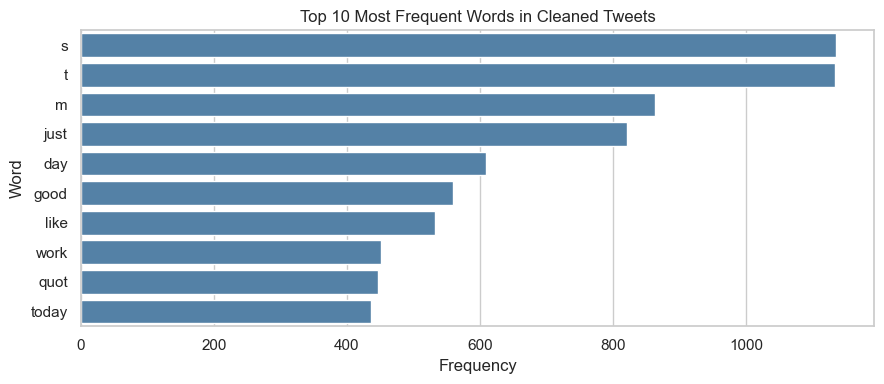

In [7]:
plt.figure(figsize=(9, 4))
sns.barplot(data=top_words, x="Frequency", y="Word", color="steelblue")
plt.title("Top 10 Most Frequent Words in Cleaned Tweets")
plt.tight_layout()
plt.show()

Frequent words show common topics and repeated language in the dataset. Very frequent but general words are not always the most useful sentiment features.

### x-xi. Extract bigrams and analyze sentiment patterns

In [8]:
all_bigram_list = []
for tokens in work_df["tokens_normalized"]:
    all_bigram_list.extend(list(bigrams(tokens)))

bigram_frequency = Counter(all_bigram_list)
top_bigrams = pd.DataFrame(
    [(" ".join(bg), count) for bg, count in bigram_frequency.most_common(10)],
    columns=["Bigram", "Frequency"],
)
top_bigrams

,Bigram,Frequency
0,don t,326
1,didn t,132
2,lt 3,95
3,just got,73
4,doesn t,65
5,t know,60
6,won t,60
7,look like,59
8,good morning,59
9,t wait,58


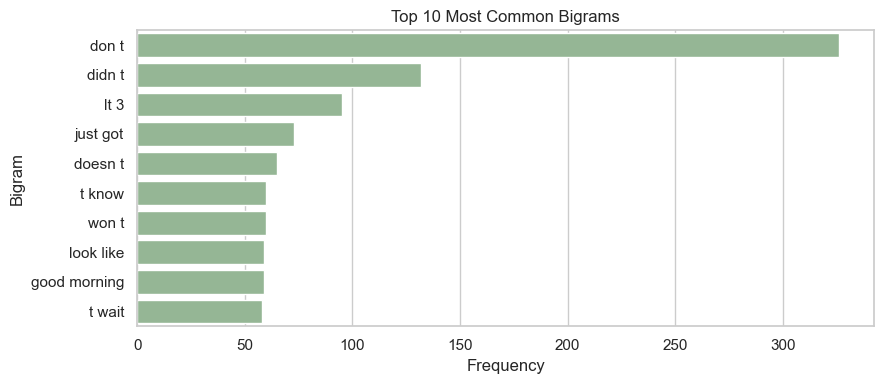

In [9]:
plt.figure(figsize=(9, 4))
sns.barplot(data=top_bigrams, x="Frequency", y="Bigram", color="darkseagreen")
plt.title("Top 10 Most Common Bigrams")
plt.tight_layout()
plt.show()

In [10]:
sentiment_phrase_patterns = ["not happy", "very good", "feel good", "miss you", "love it", "hate it"]
phrase_counts = []

for phrase in sentiment_phrase_patterns:
    count = work_df["final_clean_text"].str.contains(rf"\b{re.escape(phrase)}\b", regex=True).sum()
    phrase_counts.append((phrase, count))

pd.DataFrame(phrase_counts, columns=["Sentiment phrase", "Count in sample"])

,Sentiment phrase,Count in sample
0,not happy,0
1,very good,0
2,feel good,11
3,miss you,0
4,love it,0
5,hate it,0


Bigrams reveal sentiment patterns better than isolated words. For example, `not happy` expresses negative sentiment through negation, while `very good` strengthens positive sentiment.

### xii. Named Entity Recognition using spaCy

In [11]:
nlp = spacy.load("en_core_web_sm")
entity_rows = []

for tweet in work_df["text"].head(20).tolist():
    doc = nlp(tweet)
    for ent in doc.ents:
        if ent.label_ in {"PERSON", "ORG", "GPE", "LOC"}:
            entity_rows.append((tweet, ent.text, ent.label_))

entities_df = pd.DataFrame(entity_rows, columns=["Tweet", "Entity", "Entity type"])
entities_df.head(15)

,Tweet,Entity,Entity type
0,@mitchelmusso LOVE the album!! reply??,@mitchelmusso,ORG
1,@emilygrace_BHB I went to that concert and I remember Derek and Mark were hosting! I miss seeing BHB at the grove.,Derek,PERSON
2,@emilygrace_BHB I went to that concert and I remember Derek and Mark were hosting! I miss seeing BHB at the grove.,Mark,PERSON
3,@emilygrace_BHB I went to that concert and I remember Derek and Mark were hosting! I miss seeing BHB at the grove.,BHB,ORG
4,"@basseyworld lol, no im not a &quot;logo designer person&quot; per se.. lol, but i happen to be good and everything ...",person&quot,PERSON
5,@adampatterson Would you recommend United?,@adampatterson,PERSON
6,"Happy Mother's Day. Scott's off to Dallas, I'm off to NYC to start Hilarie's apartment move out. No Komen Race for...",Scott,ORG
7,"Happy Mother's Day. Scott's off to Dallas, I'm off to NYC to start Hilarie's apartment move out. No Komen Race for...",Dallas,GPE
8,"Happy Mother's Day. Scott's off to Dallas, I'm off to NYC to start Hilarie's apartment move out. No Komen Race for...",NYC,LOC
9,"Happy Mother's Day. Scott's off to Dallas, I'm off to NYC to start Hilarie's apartment move out. No Komen Race for...",Hilarie,PERSON


Entities influence sentiment interpretation because tweets often express opinions about specific people, organizations, or places.

## (d) Feature Engineering and Representation

### xiii-xvi. TF-IDF matrix, feature names, scores, and Bag-of-Words comparison

In [12]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(work_df["final_clean_text"])
y = work_df["target"]

X_tfidf.shape

(10000, 5000)

The TF-IDF matrix shape is `(number of documents, number of features)`. Rows are tweets, while columns are weighted word or bigram features.

In [13]:
feature_names = tfidf_vectorizer.get_feature_names_out()
first_doc_scores = X_tfidf[0].toarray().ravel()
nonzero_indices = first_doc_scores.nonzero()[0]

sample_tfidf_scores = pd.DataFrame(
    [(feature_names[i], first_doc_scores[i]) for i in nonzero_indices],
    columns=["Feature", "TF-IDF score"],
).sort_values("TF-IDF score", ascending=False).head(15)

sample_tfidf_scores

,Feature,TF-IDF score
4,song love,0.495062
2,portfolio,0.482543
5,title,0.456174
1,perfect,0.399420
3,song,0.313915
0,love,0.236418


In [14]:
bow_vectorizer = CountVectorizer(max_features=20)
bow_matrix = bow_vectorizer.fit_transform(work_df["final_clean_text"].head(100))

pd.DataFrame(
    {
        "BoW feature examples": bow_vectorizer.get_feature_names_out()[:10],
        "TF-IDF feature examples": tfidf_vectorizer.get_feature_names_out()[:10],
    }
)

,BoW feature examples,TF-IDF feature examples
0,day,00
1,don,000
2,fed,09
3,going,10
4,good,10 30
5,got,10 minute
6,just,10 year
7,like,100
8,lol,100 follower
9,lot,1000


Bag-of-Words counts terms directly. TF-IDF reduces the weight of frequent but less informative words and gives more weight to rarer, more distinctive words.

## (e) Machine Learning: Sentiment Classification

### xvii-xxii. Train-test split, Naive Bayes, Logistic Regression, and comparison

In [15]:
X_train, X_test, y_train, y_test, train_texts, test_texts = train_test_split(
    X_tfidf,
    y,
    work_df["text"],
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape

((8000, 5000), (2000, 5000))

In [16]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_predictions = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

model_comparison = pd.DataFrame(
    {
        "Tweet": test_texts.head(10).values,
        "Actual": y_test.head(10).values,
        "Naive Bayes": nb_predictions[:10],
        "Logistic Regression": lr_predictions[:10],
    }
)
model_comparison["Different prediction?"] = model_comparison["Naive Bayes"] != model_comparison["Logistic Regression"]
model_comparison

,Tweet,Actual,Naive Bayes,Logistic Regression,Different prediction?
0,"@rdavidian I love piano! My mom played, and it's my favorite music. I'd take it up again, but my fingers are too art...",0,4,4,False
1,"This is for you,Rainie!Sorry, Im late! http://bit.ly/17VC8n",4,0,0,False
2,"@kyndoll you're going to see JB? aww, lucky I want to go, but I'm broke and there's no way my mom would let me go a...",0,0,0,False
3,"Leaving for the mall soon. Then seeing 'Drag Me to Hell' After that, staying at Tessa's. Graduation tomorrow =( Lov...",4,4,4,False
4,isPlayer Has Died! Sorry,0,0,0,False
5,@yargion I need brake work on the van too. Should go do that today since I have it off.,0,4,0,True
6,Not feeling so good so a really lazy sunday today!,0,0,0,False
7,is an uncle - amca oldu,4,0,0,False
8,@tapulous You always catch me away from my computer. ?,0,0,0,False
9,Busy being the luckiest girl in the world,4,4,4,False


Naive Bayes treats words as conditionally independent evidence for a class. Logistic Regression learns feature weights that separate classes. Their assumptions differ, so they can produce different predictions.

## (f) Transformer-Based Modeling and Comparison

### xxiii-xxvii. Optional HuggingFace transformer prediction

The transformer cell is disabled by default because model loading may need internet access or cached files. Set `RUN_TRANSFORMER = True` only if the model is available.

In [17]:
RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    from transformers import pipeline
    transformer_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
    transformer_sample_texts = test_texts.head(20).tolist()
    raw_transformer_predictions = transformer_model(transformer_sample_texts)
    transformer_results = pd.DataFrame(
        {
            "Tweet": transformer_sample_texts,
            "Transformer label": [item["label"] for item in raw_transformer_predictions],
            "Transformer score": [item["score"] for item in raw_transformer_predictions],
        }
    )
else:
    transformer_results = pd.DataFrame(
        {
            "Status": ["Transformer skipped by default."],
            "How to run": ["Set RUN_TRANSFORMER = True if HuggingFace model files are available."],
        }
    )

transformer_results

,Status,How to run
0,Transformer skipped by default.,Set RUN_TRANSFORMER = True if HuggingFace model files are available.


In [18]:
traditional_comparison = pd.DataFrame(
    {
        "Tweet": test_texts.head(20).values,
        "Actual": y_test.head(20).values,
        "Naive Bayes": nb_model.predict(X_test[:20]),
        "Logistic Regression": lr_model.predict(X_test[:20]),
        "Transformer": ["Skipped"] * 20,
    }
)

traditional_comparison.head(20)

,Tweet,Actual,Naive Bayes,Logistic Regression,Transformer
0,"@rdavidian I love piano! My mom played, and it's my favorite music. I'd take it up again, but my fingers are too art...",0,4,4,Skipped
1,"This is for you,Rainie!Sorry, Im late! http://bit.ly/17VC8n",4,0,0,Skipped
2,"@kyndoll you're going to see JB? aww, lucky I want to go, but I'm broke and there's no way my mom would let me go a...",0,0,0,Skipped
3,"Leaving for the mall soon. Then seeing 'Drag Me to Hell' After that, staying at Tessa's. Graduation tomorrow =( Lov...",4,4,4,Skipped
4,isPlayer Has Died! Sorry,0,0,0,Skipped
5,@yargion I need brake work on the van too. Should go do that today since I have it off.,0,4,0,Skipped
6,Not feeling so good so a really lazy sunday today!,0,0,0,Skipped
7,is an uncle - amca oldu,4,0,0,Skipped
8,@tapulous You always catch me away from my computer. ?,0,0,0,Skipped
9,Busy being the luckiest girl in the world,4,4,4,Skipped


Transformers use attention to capture deeper context and word relationships. They can handle context better than traditional models, but they require more computation and often need pretrained model downloads.

## (g) Evaluation and Critical Analysis

### xxviii-xxxii. Metrics, confusion matrices, comparison, best model, and limitations

In [19]:
def summarize_metrics(model_name, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
    }


metrics_df = pd.DataFrame(
    [
        summarize_metrics("Naive Bayes", y_test, nb_predictions),
        summarize_metrics("Logistic Regression", y_test, lr_predictions),
    ]
)

metrics_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.7110,0.7110,0.7110,0.7110
1,Logistic Regression,0.7205,0.7207,0.7205,0.7204


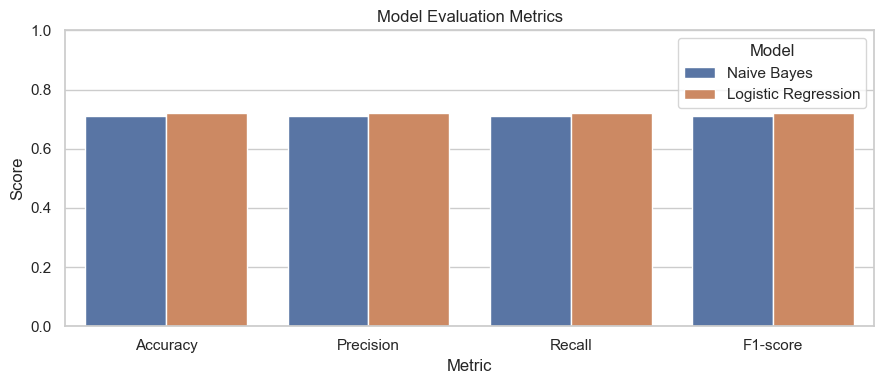

In [20]:
metrics_plot = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 4))
sns.barplot(data=metrics_plot, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Model Evaluation Metrics")
plt.tight_layout()
plt.show()

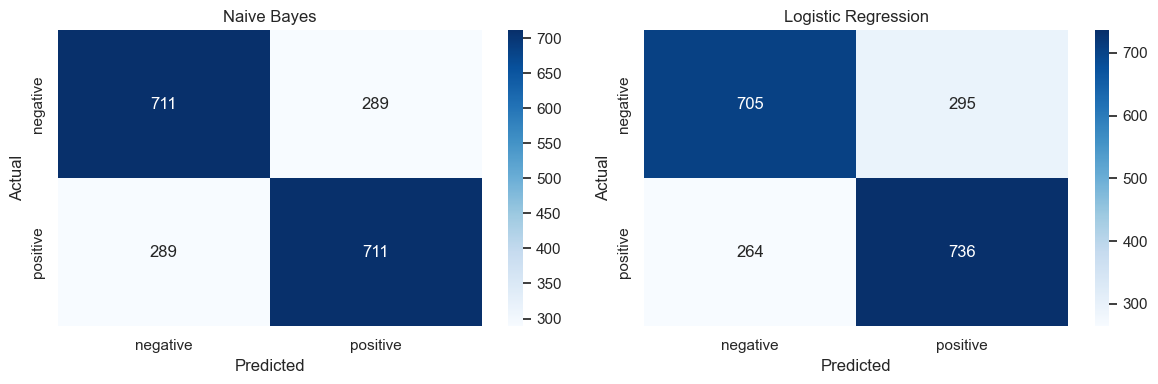

In [21]:
labels = [0, 4]
label_names = ["negative", "positive"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model_name, predictions in zip(axes, ["Naive Bayes", "Logistic Regression"], [nb_predictions, lr_predictions]):
    cm = confusion_matrix(y_test, predictions, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

The best model is selected using the F1-score because it balances precision and recall. Traditional models are fast and interpretable but struggle with sarcasm, negation, and deeper context. Transformers capture context better using attention, but they are slower and require more resources.